## Configuration 

In [ ]:
import os, sys, math, time, json, random, pickle
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

random.seed(0); np.random.seed(0)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

DATASET_ROOT   = Path("Dataset")          
CACHED_LABELS  = Path("crnn_plate") / "labels.csv"  
OUT_DIR        = Path("end_to_end_eval"); OUT_DIR.mkdir(exist_ok=True)

YOLO_POSE_WEIGHTS = "runs/pose/runs_plate_pose/final_model_s/weights/best.pt"  
CRNN_CKPT_PATH    = "recognition_results/lprnet_final.pt"                       
HEAD7_CKPT_PATH   = "recognition_results/head7_final.pt"                          

FRESH_SUBSET_SIZE  = 1500
MIN_PER_SUBSET     = 100
IMG_W, IMG_H       = 720, 1160             

LPRNET_CROP_H, LPRNET_CROP_W = 24, 94
HEAD7_CROP_H,  HEAD7_CROP_W  = 48, 168        

import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)
if DEVICE == "cuda":
    print("       ", torch.cuda.get_device_name(0))
print("CCPD root :", DATASET_ROOT.resolve(), "| exists:", DATASET_ROOT.exists())
print("Cache    :", CACHED_LABELS.resolve(), "| exists:", CACHED_LABELS.exists())

device: cuda
        NVIDIA GeForce RTX 2060
CCPD root : /home/luca/IS_Project/Dataset | exists: True
Cache    : /home/luca/IS_Project/crnn_plate/labels.csv | exists: False


## 2. CCPD parser, corner ordering, character vocabulary (reused)

In [2]:
PROVINCES = ['皖','沪','津','渝','冀','晋','蒙','辽','吉','黑','苏','浙','京',
             '闽','赣','鲁','豫','鄂','湘','粤','桂','琼','川','贵','云','藏',
             '陕','甘','青','宁','新','警','学','O']                               
ALPHABETS = ['A','B','C','D','E','F','G','H','J','K','L','M','N',
             'P','Q','R','S','T','U','V','W','X','Y','Z','O']                       
ADS = ['A','B','C','D','E','F','G','H','J','K','L','M','N',
       'P','Q','R','S','T','U','V','W','X','Y','Z',
       '0','1','2','3','4','5','6','7','8','9','O']                                 

def parse_ccpd_filename(path):
    name = Path(path).stem
    f = name.split('-')
    if len(f) != 7: return None
    f_area, f_tilt, f_bbox, f_verts, f_label, f_bright, f_blur = f
    try:
        (x1,y1),(x2,y2) = [tuple(map(int,p.split('&'))) for p in f_bbox.split('_')]
        verts = [tuple(map(int,p.split('&'))) for p in f_verts.split('_')]
        if len(verts) != 4: return None
        idxs = list(map(int, f_label.split('_')))
        if len(idxs) != 7: return None
        plate = PROVINCES[idxs[0]] + ALPHABETS[idxs[1]] + ''.join(ADS[i] for i in idxs[2:])
    except (ValueError, IndexError):
        return None
    return {"path": str(path), "bbox": (x1,y1,x2,y2), "vertices": verts, "plate": plate}

def order_corners(pts):
    '''Sort 4 points into TL, TR, BR, BL.'''
    pts = np.asarray(pts, dtype=np.float32)
    s = pts.sum(axis=1); d = np.diff(pts, axis=1).ravel()
    return np.stack([pts[np.argmin(s)], pts[np.argmin(d)],
                     pts[np.argmax(s)], pts[np.argmax(d)]])

def discover_subset(p: Path) -> str:
    try:
        rel = p.relative_to(DATASET_ROOT); parts = rel.parts
        return parts[0] if len(parts) > 1 else "unknown"
    except ValueError:
        return "unknown"

REAL_PROVINCES = [p for p in PROVINCES if p != 'O']
REAL_LETTERS   = [a for a in ALPHABETS if a != 'O']
REAL_DIGITS    = [d for d in ADS if d.isdigit()]
VOCAB = ['<blank>'] + REAL_PROVINCES + REAL_LETTERS + REAL_DIGITS
CHAR2IDX = {c: i for i, c in enumerate(VOCAB)}
IDX2CHAR = {i: c for c, i in CHAR2IDX.items()}
N_CLASSES = len(VOCAB); BLANK_IDX = 0
print(f"vocabulary: {N_CLASSES} classes (incl. blank)")

vocabulary: 68 classes (incl. blank)


## Build the fresh subset


In [3]:
def gather_by_subset(root, excluded_stems: set):
    by = {}
    for p in root.rglob("*.jpg"):
        if p.stem in excluded_stems: continue
        by.setdefault(discover_subset(p), []).append(p)
    return by

def stratified_sample(by_subset, max_images, min_per_subset, seed=0):
    rng = random.Random(seed)
    subsets = {k: list(v) for k,v in by_subset.items()}
    for v in subsets.values(): rng.shuffle(v)
    total = sum(len(v) for v in subsets.values())
    if max_images is None or max_images >= total:
        return subsets
    alloc = {k: min(min_per_subset, len(v)) for k,v in subsets.items()}
    used = sum(alloc.values()); remaining = max_images - used
    if remaining > 0:
        leftover = {k: len(v)-alloc[k] for k,v in subsets.items()}
        lt = sum(leftover.values())
        if lt > 0:
            for k in subsets:
                add = int(round(remaining * leftover[k] / lt))
                alloc[k] = min(len(subsets[k]), alloc[k]+add)
    over = sum(alloc.values()) - max_images
    if over > 0:
        for k in sorted(alloc, key=lambda z: alloc[z], reverse=True):
            cut = min(over, alloc[k]-min(min_per_subset, len(subsets[k])))
            alloc[k] -= max(cut,0); over -= max(cut,0)
            if over <= 0: break
    return {k: subsets[k][:alloc[k]] for k in subsets}

# Load excluded stems from the cached labels 
excluded = set()
if CACHED_LABELS.exists():
    cached_df = pd.read_csv(CACHED_LABELS)
    excluded = set(Path(p).stem for p in cached_df["path"])
    print(f"Excluding {len(excluded):,} images previously used in any cache")
else:
    print("⚠ no cached labels.csv found — fresh subset will be drawn from the entire dataset")

by_subset = gather_by_subset(DATASET_ROOT, excluded)
print("\nAvailable (untouched) by subset:", {k: len(v) for k,v in by_subset.items()})

sampled = stratified_sample(by_subset, FRESH_SUBSET_SIZE, MIN_PER_SUBSET, seed=42)
fresh_paths = []
for subset, plist in sampled.items():
    for p in plist:
        fresh_paths.append({"path": str(p), "subset": subset, "stem": p.stem})
fresh_df = pd.DataFrame(fresh_paths)
print(f"\nFresh subset built: {len(fresh_df)} images")
print(fresh_df["subset"].value_counts().sort_index().to_string())

⚠ no cached labels.csv found — fresh subset will be drawn from the entire dataset

Available (untouched) by subset: {'ccpd_fn': 20967, 'ccpd_challenge': 50003, 'ccpd_weather': 9999, 'ccpd_blur': 20611, 'ccpd_np': 3036, 'ccpd_db': 10132, 'ccpd_rotate': 10053, 'ccpd_base': 199996, 'ccpd_tilt': 30216}

Fresh subset built: 1500 images
subset
ccpd_base         438
ccpd_blur         135
ccpd_challenge    185
ccpd_db           117
ccpd_fn           135
ccpd_np           105
ccpd_rotate       117
ccpd_tilt         151
ccpd_weather      117


In [4]:
rows = []
for _, r in fresh_df.iterrows():
    rec = parse_ccpd_filename(r["path"])
    if rec is None:
        rows.append({"path": r["path"], "subset": r["subset"], "plate": None,
                     "vertices_gt": None, "skipped": True})
        continue
    rows.append({"path": r["path"], "subset": r["subset"], "plate": rec["plate"],
                 "vertices_gt": rec["vertices"], "skipped": False})

fresh_df = pd.DataFrame(rows)
fresh_df = fresh_df[~fresh_df["skipped"]].reset_index(drop=True)
print(f"Fresh subset after parsing: {len(fresh_df)}")
print(fresh_df.head(3))

Fresh subset after parsing: 1395
                                                path   subset    plate  \
0  Dataset/ccpd_fn/0789-2_33-99&471_595&604-595&6...  ccpd_fn  皖A54417   
1  Dataset/ccpd_fn/0759-13_31-176&465_515&652-515...  ccpd_fn  苏A6T3S3   
2  Dataset/ccpd_fn/0048-0_3-254&520_364&557-364&5...  ccpd_fn  皖AJM858   

                                        vertices_gt  skipped  
0   [(595, 604), (164, 582), (99, 471), (530, 493)]    False  
1  [(515, 652), (215, 581), (176, 465), (476, 536)]    False  
2  [(364, 557), (256, 557), (254, 520), (362, 520)]    False  


##  YOLO-pose 


In [5]:
try:
    from ultralytics import YOLO
except ImportError:
    raise SystemExit("Install ultralytics: pip install ultralytics")

assert Path(YOLO_POSE_WEIGHTS).exists(), f"YOLO-pose weights not found at {YOLO_POSE_WEIGHTS}"
pose_model = YOLO(YOLO_POSE_WEIGHTS)
print(f"Loaded YOLO-pose model from {YOLO_POSE_WEIGHTS}")

predicted_corners = []   
detection_conf    = []
t0 = time.time()

paths = fresh_df["path"].tolist()
for i in range(0, len(paths), 32):
    batch = paths[i:i+32]
    results = pose_model.predict(batch, imgsz=640, device=DEVICE, verbose=False)
    for r in results:
        if r.keypoints is None or len(r.keypoints) == 0:
            predicted_corners.append(None); detection_conf.append(0.0)
            continue
        confs = r.boxes.conf.cpu().numpy() if r.boxes is not None and r.boxes.conf is not None else np.array([1.0])
        best_idx = int(np.argmax(confs))
        kp = r.keypoints.xy.cpu().numpy()[best_idx]   
        predicted_corners.append(kp.tolist())
        detection_conf.append(float(confs[best_idx]))
    if (i+32) % 320 == 0 or i+32 >= len(paths):
        dt = time.time() - t0
        n = min(i+32, len(paths))
        print(f"  {n}/{len(paths)}  ({dt:.0f}s, {n/dt:.1f} img/s)")

fresh_df["corners_pred"] = predicted_corners
fresh_df["detection_conf"] = detection_conf

n_missed = (fresh_df["corners_pred"].isna()).sum()
print(f"\nPose miss rate: {n_missed}/{len(fresh_df)} = {n_missed/len(fresh_df):.4f}")
print(f"Pose detection mean confidence (on hits): {fresh_df.loc[fresh_df['corners_pred'].notna(), 'detection_conf'].mean():.3f}")

Loaded YOLO-pose model from runs/pose/runs_plate_pose/final_model/weights/best.pt
  320/1395  (8s, 38.0 img/s)
  640/1395  (16s, 39.8 img/s)
  960/1395  (24s, 40.3 img/s)
  1280/1395  (32s, 40.6 img/s)
  1395/1395  (34s, 40.6 img/s)

Pose miss rate: 0/1395 = 0.0000
Pose detection mean confidence (on hits): 0.820


## Corner localisation error

For each image where YOLO-pose detected the plate, compute the mean pixel distance between predicted corners and ground-truth corners (both ordered TL/TR/BR/BL). This number, plus the pose miss rate, are the two end-to-end-specific metrics that explain *why* end-to-end accuracy will be lower than rectified-crop accuracy.

In [6]:
def corner_error_px(gt_verts, pred_verts):
    '''Mean of per-corner Euclidean distances after ordering both into TL,TR,BR,BL.'''
    gt   = order_corners(gt_verts)
    pred = order_corners(pred_verts)
    return float(np.linalg.norm(gt - pred, axis=1).mean())

errors = []
for _, r in fresh_df.iterrows():
    if r["corners_pred"] is None:
        errors.append(None)
    else:
        errors.append(corner_error_px(r["vertices_gt"], r["corners_pred"]))
fresh_df["corner_err_px"] = errors

hits = fresh_df["corner_err_px"].dropna()
print(f"Corner localisation error (pixels), detected plates only:")
print(f"  mean   : {hits.mean():.2f} px")
print(f"  median : {hits.median():.2f} px")
print(f"  p90    : {hits.quantile(0.90):.2f} px")
print(f"  max    : {hits.max():.2f} px")

# Per-subset breakdown — the hard subsets (rotate/tilt) usually have larger errors
print("\nPer-subset corner error (median px):")
print(fresh_df.groupby("subset")["corner_err_px"].median().sort_values().to_string())

Corner localisation error (pixels), detected plates only:
  mean   : 7.08 px
  median : 5.08 px
  p90    : 11.90 px
  max    : 350.89 px

Per-subset corner error (median px):
subset
ccpd_base         4.012990
ccpd_weather      4.518053
ccpd_challenge    4.568951
ccpd_blur         5.305089
ccpd_rotate       6.888899
ccpd_tilt         6.952939
ccpd_fn           8.059778
ccpd_db           8.238006


## Rectify plates from predicted corners

In [7]:
def rectify_plate_bgr(img_bgr, vertices, out_w, out_h):
    corners = order_corners(vertices).astype(np.float32)
    dst = np.array([[0,0],[out_w-1,0],[out_w-1,out_h-1],[0,out_h-1]], dtype=np.float32)
    M = cv2.getPerspectiveTransform(corners, dst)
    return cv2.warpPerspective(img_bgr, M, (out_w, out_h))


CROPS_DIR = OUT_DIR / "crops"; CROPS_DIR.mkdir(exist_ok=True)

crop_paths = []
for i, r in fresh_df.iterrows():
    if r["corners_pred"] is None:
        crop_paths.append(None); continue
    img = cv2.imread(r["path"])
    if img is None:
        crop_paths.append(None); continue
    try:
        crop = rectify_plate_bgr(img, r["corners_pred"], LPRNET_CROP_W, LPRNET_CROP_H)
    except Exception:
        crop_paths.append(None); continue
    p = CROPS_DIR / f"{Path(r['path']).stem}.jpg"
    cv2.imwrite(str(p), crop)
    crop_paths.append(str(p))

fresh_df["crop_path"] = crop_paths
print(f"Rectified crops written: {fresh_df['crop_path'].notna().sum()}/{len(fresh_df)}")

Rectified crops written: 1395/1395


/tmp/ipykernel_69301/4106978596.py:8: UserWarning: Glyph 20140 (\N{CJK UNIFIED IDEOGRAPH-4EAC}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_69301/4106978596.py:8: UserWarning: Glyph 30358 (\N{CJK UNIFIED IDEOGRAPH-7696}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_69301/4106978596.py:8: UserWarning: Glyph 27993 (\N{CJK UNIFIED IDEOGRAPH-6D59}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/home/luca/.venv-paddle/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20140 (\N{CJK UNIFIED IDEOGRAPH-4EAC}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/luca/.venv-paddle/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30358 (\N{CJK UNIFIED IDEOGRAPH-7696}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/luca/.venv-paddle/lib/python3.13/site-packages/IPython/core/pylabto

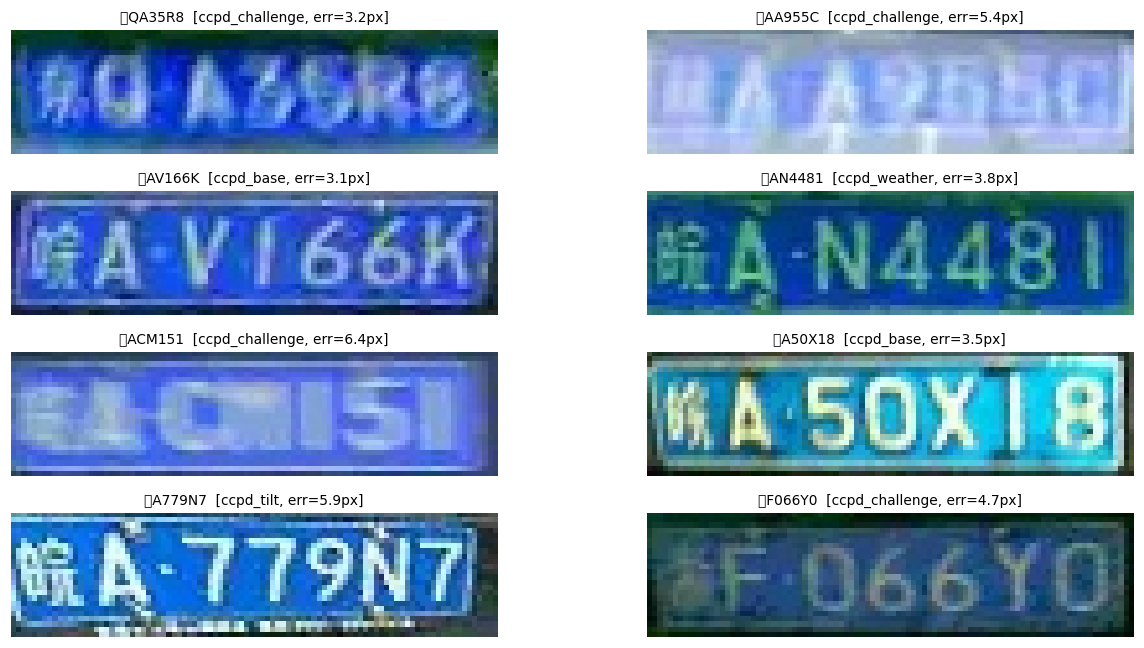

In [9]:
subset = fresh_df[fresh_df["crop_path"].notna()].sample(8, random_state=0).reset_index(drop=True)
fig, axes = plt.subplots(4, 2, figsize=(12, 6))
for ax, (_, r) in zip(axes.ravel(), subset.iterrows()):
    img = cv2.imread(r["crop_path"])
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{r['plate']}  [{r['subset']}, err={r['corner_err_px']:.1f}px]", fontsize=9)
    ax.axis("off")
plt.tight_layout(); plt.show()

## LPRNet 



In [11]:
import torch.nn as nn
import torch.nn.functional as F

class small_basic_block(nn.Module):
    def __init__(self, ch_in, ch_out):
        super().__init__()
        ch_mid = ch_out // 4
        self.block = nn.Sequential(
            nn.Conv2d(ch_in,  ch_mid, kernel_size=1), nn.ReLU(),
            nn.Conv2d(ch_mid, ch_mid, kernel_size=(3,1), padding=(1,0)), nn.ReLU(),
            nn.Conv2d(ch_mid, ch_mid, kernel_size=(1,3), padding=(0,1)), nn.ReLU(),
            nn.Conv2d(ch_mid, ch_out, kernel_size=1),
        )
    def forward(self, x): return self.block(x)

class LPRNet(nn.Module):
    def __init__(self, class_num=N_CLASSES, dropout_rate=0.5):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=1),
            small_basic_block(64, 128), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=(1,2)),
            small_basic_block(128, 256), nn.BatchNorm2d(256), nn.ReLU(),
            small_basic_block(256, 256), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=(1,2)),
            nn.Dropout(dropout_rate),
            nn.Conv2d(256, 256, kernel_size=(1,4), stride=1),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Conv2d(256, class_num, kernel_size=(13,1)),
            nn.BatchNorm2d(class_num), nn.ReLU(),
        )
        self.container = nn.Conv2d(64+128+256+class_num, class_num, kernel_size=1)
    def forward(self, x):
        keep = {2, 6, 13, 22}
        feats = []
        for i, layer in enumerate(self.backbone):
            x = layer(x)
            if i in keep: feats.append(x)
        H_out, W_out = feats[-1].shape[2], feats[-1].shape[3]
        normed = []
        for f in feats:
            f_n = f.div(f.pow(2).mean().clamp(min=1e-8))
            if f.shape[2:] != (H_out, W_out):
                f_n = F.adaptive_avg_pool2d(f_n, (H_out, W_out))
            normed.append(f_n)
        cat = torch.cat(normed, dim=1)
        logits = self.container(cat).mean(dim=2)         # B x V x W
        return logits.permute(2, 0, 1).contiguous()       # T x B x V

def greedy_ctc_decode(logits_TBV):
    idx = logits_TBV.argmax(dim=2).cpu().numpy()
    T, B = idx.shape
    out = []
    for b in range(B):
        seq = []; prev = -1
        for t in range(T):
            c = int(idx[t, b])
            if c != prev and c != BLANK_IDX:
                seq.append(IDX2CHAR[c])
            prev = c
        out.append(''.join(seq))
    return out

def to_lprnet_tensor(img_bgr):
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    if img.shape[:2] != (LPRNET_CROP_H, LPRNET_CROP_W):
        img = cv2.resize(img, (LPRNET_CROP_W, LPRNET_CROP_H))
    x = (img.astype(np.float32) / 255.0 - 0.5) / 0.5
    return torch.from_numpy(x).permute(2, 0, 1)

# Load checkpoint
if Path(CRNN_CKPT_PATH).exists():
    lprnet = LPRNet(N_CLASSES).to(DEVICE)
    ckpt = torch.load(CRNN_CKPT_PATH, map_location=DEVICE)
    state = ckpt.get("model_state_dict", ckpt)   # handle wrapped or raw state-dict
    lprnet.load_state_dict(state)
    lprnet.eval()
    print(f"Loaded LPRNet from {CRNN_CKPT_PATH}")

    # Run inference
    preds_lprnet = []
    BATCH = 64
    rows_with_crop = fresh_df[fresh_df["crop_path"].notna()].reset_index(drop=True)
    t0 = time.time()
    for i in range(0, len(rows_with_crop), BATCH):
        batch = rows_with_crop.iloc[i:i+BATCH]
        xs = []
        for _, r in batch.iterrows():
            img = cv2.imread(r["crop_path"])
            xs.append(to_lprnet_tensor(img))
        xb = torch.stack(xs).to(DEVICE)
        with torch.no_grad():
            logits = lprnet(xb)
        preds_lprnet.extend(greedy_ctc_decode(logits))
    print(f"LPRNet inference: {len(preds_lprnet)} preds in {time.time()-t0:.1f}s")

    # Map back to fresh_df (None for images with no pose detection)
    pred_map = dict(zip(rows_with_crop["path"], preds_lprnet))
    fresh_df["pred_lprnet"] = fresh_df["path"].map(pred_map)
else:
    print(f"⚠ LPRNet checkpoint not found at {CRNN_CKPT_PATH} — skipping this recogniser")
    fresh_df["pred_lprnet"] = None

Loaded LPRNet from lpnr_plate/crnn_final.pt
LPRNet inference: 1395 preds in 0.8s


## 7-head CNN 



In [16]:
# ─── Recogniser B: 7-head CNN — matches the trained checkpoint exactly ─────
HEAD7_CROP_H, HEAD7_CROP_W = 24, 94

# Build the vocab in the same way as the unified notebook (likely 67 classes)
HEAD7_VOCAB       = REAL_PROVINCES + REAL_LETTERS + REAL_DIGITS
HEAD7_CHAR2IDX    = {c: i for i, c in enumerate(HEAD7_VOCAB)}
HEAD7_IDX2CHAR    = {i: c for c, i in HEAD7_CHAR2IDX.items()}

class SevenHeadCNN(nn.Module):
    """7-head plate recogniser with shared vocabulary across 7 heads."""
    def __init__(self, n_classes, n_slots=7):
        super().__init__()
        self.n_slots = n_slots
        def blk(ci, co):
            return nn.Sequential(
                nn.Conv2d(ci, co, 3, 1, 1),
                nn.BatchNorm2d(co),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )
        self.backbone = nn.Sequential(
            blk(3, 32), blk(32, 64), blk(64, 128),
            nn.AdaptiveAvgPool2d(1),
        )
        self.heads = nn.ModuleList([nn.Linear(128, n_classes) for _ in range(n_slots)])

    def forward(self, x):
        f = self.backbone(x).flatten(1)
        return torch.stack([h(f) for h in self.heads], dim=1)


def to_head7_tensor(img_bgr):
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)
    if img.shape[:2] != (HEAD7_CROP_H, HEAD7_CROP_W):
        img = cv2.resize(img, (HEAD7_CROP_W, HEAD7_CROP_H))
    x = img / 127.5 - 1.0
    return torch.from_numpy(x).permute(2, 0, 1)


if Path(HEAD7_CKPT_PATH).exists():
    ckpt = torch.load(HEAD7_CKPT_PATH, map_location=DEVICE)
    state = ckpt.get("model_state_dict", ckpt)

    head_weight_shape = state["heads.0.weight"].shape    
    n_classes_ckpt = int(head_weight_shape[0])
    print(f"Checkpoint heads have n_classes = {n_classes_ckpt}")
    print(f"Local HEAD7_VOCAB has {len(HEAD7_VOCAB)} entries")

    ckpt_vocab = ckpt.get("vocab")
    if ckpt_vocab is not None and len(ckpt_vocab) == n_classes_ckpt:
        print(f"  using vocab from checkpoint ({len(ckpt_vocab)} chars)")
        HEAD7_VOCAB    = list(ckpt_vocab)
        HEAD7_CHAR2IDX = {c: i for i, c in enumerate(HEAD7_VOCAB)}
        HEAD7_IDX2CHAR = {i: c for c, i in HEAD7_CHAR2IDX.items()}
    elif len(HEAD7_VOCAB) != n_classes_ckpt:
        while len(HEAD7_VOCAB) < n_classes_ckpt:
            HEAD7_VOCAB.append("?")
        HEAD7_CHAR2IDX = {c: i for i, c in enumerate(HEAD7_VOCAB)}
        HEAD7_IDX2CHAR = {i: c for c, i in HEAD7_CHAR2IDX.items()}

    HEAD7_NUM_CLASSES = len(HEAD7_VOCAB)

    head7 = SevenHeadCNN(n_classes=HEAD7_NUM_CLASSES).to(DEVICE)
    head7.load_state_dict(state)
    head7.eval()
    print(f"✓ Loaded 7-head CNN from {HEAD7_CKPT_PATH}")

    def decode_head7(logits_BSV):
        idx = logits_BSV.argmax(dim=2).cpu().numpy()
        return ["".join(HEAD7_IDX2CHAR[int(idx[b, k])] for k in range(7))
                for b in range(idx.shape[0])]

    preds_head7 = []
    rows_with_crop = fresh_df[fresh_df["crop_path"].notna()].reset_index(drop=True)
    BATCH = 64
    t0 = time.time()
    for i in range(0, len(rows_with_crop), BATCH):
        batch = rows_with_crop.iloc[i:i+BATCH]
        xs = [to_head7_tensor(cv2.imread(r["crop_path"])) for _, r in batch.iterrows()]
        xb = torch.stack(xs).to(DEVICE)
        with torch.no_grad():
            logits = head7(xb)
        preds_head7.extend(decode_head7(logits))
    print(f"7-head CNN inference: {len(preds_head7)} preds in {time.time()-t0:.1f}s")

    pred_map = dict(zip(rows_with_crop["path"], preds_head7))
    fresh_df["pred_head7"] = fresh_df["path"].map(pred_map)
else:
    print(f"⚠ 7-head CNN checkpoint not found at {HEAD7_CKPT_PATH} — skipping")
    fresh_df["pred_head7"] = None

Checkpoint heads have n_classes = 68
Local HEAD7_VOCAB has 67 entries
✓ Loaded 7-head CNN from runs_plate_recog/seven_warp/best.pt
7-head CNN inference: 1395 preds in 0.2s


## 11. Recogniser C — PaddleOCR (zero-shot baseline)

PaddleOCR doesn't need a checkpoint — it downloads `PP-OCRv5_server_rec` on first run. Make sure you're in the venv where PaddleOCR is installed (the one set up for the `paddleocr_baseline.ipynb` notebook). If you get an import error, this section will skip cleanly.

In [19]:
try:
    from paddleocr import TextRecognition
    paddle_available = True
except ImportError:
    print("⚠ PaddleOCR not installed in this env. Skip this section or switch to your paddle venv.")
    paddle_available = False

def extract_text_and_score(res):
    if res is None: return "", 0.0
    for txt_key, sc_key in [("rec_text","rec_score"), ("text","score")]:
        if hasattr(res, "json"):
            try:
                d = res.json
                if isinstance(d, dict) and txt_key in d:
                    return str(d[txt_key]), float(d.get(sc_key, 0.0))
            except Exception: pass
        if hasattr(res, "get") and res.get(txt_key) is not None:
            return str(res[txt_key]), float(res.get(sc_key, 0.0))
        if hasattr(res, txt_key):
            return str(getattr(res, txt_key)), float(getattr(res, sc_key, 0.0))
    if isinstance(res, (tuple, list)) and len(res) >= 2:
        try: return str(res[0]), float(res[1])
        except Exception: pass
    return "", 0.0

VALID_LETTERS = set(REAL_LETTERS)
VALID_DIGITS  = set(REAL_DIGITS)
VALID_PROVS   = set(REAL_PROVINCES)
def clean_prediction(raw):
    if raw is None: return ""
    s = str(raw).strip().upper()
    s = "".join(c for c in s if not c.isspace() and c not in ".,-•·")
    all_valid = VALID_LETTERS | VALID_DIGITS | VALID_PROVS
    s = "".join(c for c in s if c in all_valid)
    return s[:7]

if paddle_available:
    recognizer = TextRecognition(model_name="PP-OCRv5_server_rec")
    rows_with_crop = fresh_df[fresh_df["crop_path"].notna()].reset_index(drop=True)
    crop_paths = rows_with_crop["crop_path"].tolist()
    BATCH = 16
    raw_preds = []
    t0 = time.time()
    for i in range(0, len(crop_paths), BATCH):
        batch = crop_paths[i:i+BATCH]
        outs = recognizer.predict(input=batch, batch_size=len(batch))
        for res in outs:
            raw, _ = extract_text_and_score(res)
            raw_preds.append(clean_prediction(raw))
    print(f"PaddleOCR inference: {len(raw_preds)} preds in {time.time()-t0:.1f}s")
    pred_map = dict(zip(rows_with_crop["path"], raw_preds))
    fresh_df["pred_paddle"] = fresh_df["path"].map(pred_map)
else:
    fresh_df["pred_paddle"] = None

Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/luca/.paddlex/official_models/PP-OCRv5_server_rec`.


PaddleOCR inference: 1395 preds in 7.4s


##  end-to-end accuracy for each recogniser

For each image:
- If YOLO-pose **missed** the plate, all recognisers count it as wrong (their prediction is `None`).
- If YOLO-pose detected but the recogniser produced the wrong string, also wrong.
- Only if both stages succeed does the image count as correct.


In [20]:
def evaluate_recogniser(df, pred_col):
    if df[pred_col].isna().all():
        return None
    # End-to-end: pred_col is None → miss → wrong; otherwise compare to truth
    full = (df[pred_col].fillna("") == df["plate"]).sum()
    n = len(df)
    # Conditional on detection
    detected = df[df["corners_pred"].notna() & df[pred_col].notna()]
    full_cond = (detected[pred_col] == detected["plate"]).sum()
    n_cond = len(detected)
    # Per-subset (end-to-end)
    per_subset = (df.assign(correct=df[pred_col].fillna("") == df["plate"])
                    .groupby("subset")["correct"].agg(["mean","sum","count"])
                    .rename(columns={"mean":"e2e_acc","sum":"correct","count":"n"})
                    .sort_values("e2e_acc", ascending=False))
    return {
        "e2e_full_plate_acc"   : full / max(n, 1),
        "n_e2e"                : n,
        "cond_full_plate_acc"  : full_cond / max(n_cond, 1) if n_cond else 0,
        "n_cond"               : n_cond,
        "per_subset"           : per_subset,
    }

summaries = {}
for label, col in [("LPRNet", "pred_lprnet"),
                   ("7-head CNN", "pred_head7"),
                   ("PaddleOCR (zero-shot)", "pred_paddle")]:
    s = evaluate_recogniser(fresh_df, col)
    summaries[label] = s

# Headline table
print("="*70)
print("END-TO-END EVALUATION  (YOLO-pose → rectify → recogniser)")
print("="*70)
print(f"\nFresh subset:                 {len(fresh_df)} images")
print(f"YOLO-pose miss rate:          {fresh_df['corners_pred'].isna().sum()}/{len(fresh_df)}"
      f" = {fresh_df['corners_pred'].isna().mean():.4f}")
hits = fresh_df['corner_err_px'].dropna()
print(f"Corner localisation (median): {hits.median():.2f} px (on detected plates)")

print(f"\n{'Recogniser':<25} {'E2E full-plate':>16} {'cond. on detect':>18}  {'n':>6}")
print("-"*72)
for label, s in summaries.items():
    if s is None:
        print(f"{label:<25} {'(skipped)':>16}"); continue
    print(f"{label:<25} {s['e2e_full_plate_acc']:>16.4f} {s['cond_full_plate_acc']:>18.4f}  {s['n_e2e']:>6}")

END-TO-END EVALUATION  (YOLO-pose → rectify → recogniser)

Fresh subset:                 1395 images
YOLO-pose miss rate:          0/1395 = 0.0000
Corner localisation (median): 5.08 px (on detected plates)

Recogniser                  E2E full-plate    cond. on detect       n
------------------------------------------------------------------------
LPRNet                              0.7663             0.7663    1395
7-head CNN                          0.0136             0.0136    1395
PaddleOCR (zero-shot)               0.6452             0.6452    1395


## Per-subset end-to-end breakdown 



In [22]:
# Combine per-subset accuracies into one wide table
combined = None
for label, s in summaries.items():
    if s is None: continue
    sub = s["per_subset"]["e2e_acc"].rename(label).to_frame()
    combined = sub if combined is None else combined.join(sub, how="outer")
# Add count column for reference
combined["n"] = next(s for s in summaries.values() if s is not None)["per_subset"]["n"]
combined = combined[["n"] + [c for c in combined.columns if c != "n"]]
display(combined.round(4))

,n,LPRNet,PaddleOCR (zero-shot)
subset,,,
ccpd_base,438,0.9909,0.8950
ccpd_blur,135,0.5852,0.1111
ccpd_challenge,185,0.7405,0.3405
ccpd_db,117,0.6068,0.3504
ccpd_fn,135,0.7333,0.5852
ccpd_rotate,117,0.9231,0.8120
ccpd_tilt,151,0.7881,0.7086
ccpd_weather,117,0.9829,0.8547


In [23]:
# These are the rectified-crop numbers from the recognition notebooks.
# Fill in whatever you actually measured on the frozen test set there.
RECTIFIED_CROP_BASELINE = {
    "LPRNet":               None,    # e.g. 0.85 — fill from crnn_recognition.ipynb section 11
    "7-head CNN":           0.50,    # the ~0.5 number you reported earlier
    "PaddleOCR (zero-shot)": None,   # fill from paddleocr_baseline.ipynb section 7
}

print("End-to-end gap (rectified-crop acc → end-to-end acc):")
print(f"{'Recogniser':<25} {'rect. crop':>12} {'end-to-end':>12} {'gap':>10}")
print("-"*65)
for label, s in summaries.items():
    if s is None: continue
    rect = RECTIFIED_CROP_BASELINE.get(label)
    e2e  = s["e2e_full_plate_acc"]
    if rect is None:
        print(f"{label:<25} {'(fill in)':>12} {e2e:>12.4f} {'?':>10}")
    else:
        gap = rect - e2e
        print(f"{label:<25} {rect:>12.4f} {e2e:>12.4f} {gap:>+10.4f}")

End-to-end gap (rectified-crop acc → end-to-end acc):
Recogniser                  rect. crop   end-to-end        gap
-----------------------------------------------------------------
LPRNet                       (fill in)       0.8330          ?
PaddleOCR (zero-shot)        (fill in)       0.6394          ?


/tmp/ipykernel_155928/1574988371.py:17: UserWarning: Glyph 20140 (\N{CJK UNIFIED IDEOGRAPH-4EAC}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_155928/1574988371.py:17: UserWarning: Glyph 35947 (\N{CJK UNIFIED IDEOGRAPH-8C6B}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_155928/1574988371.py:17: UserWarning: Glyph 30358 (\N{CJK UNIFIED IDEOGRAPH-7696}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_155928/1574988371.py:17: UserWarning: Glyph 27993 (\N{CJK UNIFIED IDEOGRAPH-6D59}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/home/luca/.venv-paddle/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20140 (\N{CJK UNIFIED IDEOGRAPH-4EAC}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/luca/.venv-paddle/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35947 (\N{CJK UNI

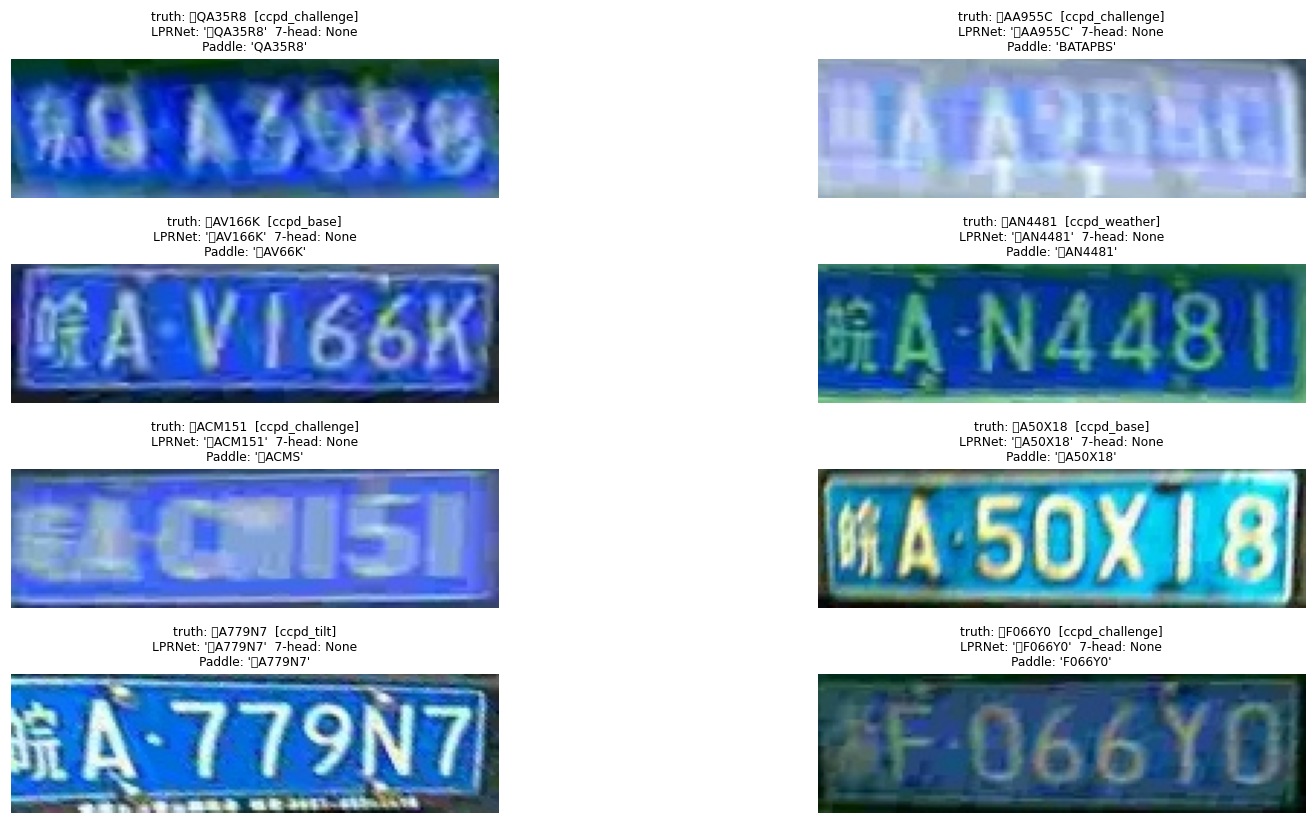

In [ ]:
sample = fresh_df.sample(min(8, len(fresh_df)), random_state=0).reset_index(drop=True)
cols, rows = 2, math.ceil(len(sample) / 2)
fig, axes = plt.subplots(rows, cols, figsize=(cols*8, rows*1.9))
axes = np.array(axes).reshape(-1)
for ax, (_, r) in zip(axes, sample.iterrows()):
    path = r["crop_path"] or r["path"]
    img = cv2.imread(path)
    if img is None: ax.axis("off"); continue
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    title = (f"truth: {r['plate']}  [{r['subset']}]\n"
             f"LPRNet: {r.get('pred_lprnet')!r}  "
             f"7-head: {r.get('pred_head7')!r}\n"
             f"Paddle: {r.get('pred_paddle')!r}")
    ax.set_title(title, fontsize=8)
    ax.axis("off")
for ax in axes[len(sample):]: ax.axis("off")
plt.tight_layout(); plt.show()

In [25]:
# Per-image predictions
fresh_df.to_csv(OUT_DIR / "e2e_predictions.csv", index=False)

# Summary JSON
def _to_serializable(o):
    if isinstance(o, pd.DataFrame):
        return o.reset_index().to_dict(orient="records")
    return o

summary_out = {
    "fresh_subset_size": int(len(fresh_df)),
    "pose_miss_rate":    float(fresh_df["corners_pred"].isna().mean()),
    "corner_err_median_px": float(fresh_df["corner_err_px"].dropna().median()),
    "corner_err_mean_px":   float(fresh_df["corner_err_px"].dropna().mean()),
    "recognisers": {
        label: {
            "e2e_full_plate_acc":  s["e2e_full_plate_acc"],
            "cond_full_plate_acc": s["cond_full_plate_acc"],
            "per_subset":          _to_serializable(s["per_subset"]),
        } for label, s in summaries.items() if s is not None
    },
}
with open(OUT_DIR / "e2e_summary.json", "w") as f:
    json.dump(summary_out, f, indent=2, ensure_ascii=False)
print(f"Saved:")
print(f"  {OUT_DIR/'e2e_predictions.csv'}  ({len(fresh_df)} rows)")
print(f"  {OUT_DIR/'e2e_summary.json'}")

Saved:
  end_to_end_eval/e2e_predictions.csv  (1395 rows)
  end_to_end_eval/e2e_summary.json


# Video pipeline


In [ ]:
INPUT_VIDEO   = Path("demo_clip.webm")              
OUTPUT_VIDEO  = OUT_DIR / "annotated.mp4"

# "lprnet", "head7", "paddle".
RECOGNISER    = "lprnet"

PROCESS_EVERY_N = 2

TRACK_DIST_PX  = 80      # max bbox-center distance (px) for "same plate" across frames
TRACK_TTL      = 30      # forget a track if it hasn't been seen for this many frames
VOTE_WINDOW    = 30      # how many recent predictions to include in the majority vote
MIN_VOTE_CONF  = 3       # need at least this many votes before we trust a label

DRAW_BOX_COLOR = (50, 220, 50)    
DRAW_BOX_THICK = 3
DRAW_FONT_SIZE = 28                
DRAW_FONT_PATH = None              

print(f"Input video : {INPUT_VIDEO} (exists: {INPUT_VIDEO.exists()})")
print(f"Output video: {OUTPUT_VIDEO}")
print(f"Recogniser  : {RECOGNISER}")
print(f"Process every {PROCESS_EVERY_N} frames; vote window = {VOTE_WINDOW}")

Input video : demo_clip.webm (exists: True)
Output video: end_to_end_eval/annotated.mp4
Recogniser  : lprnet
Process every 2 frames; vote window = 30


In [27]:
from PIL import Image, ImageDraw, ImageFont

def _find_cjk_font():
    '''Look for any installed font that can render Chinese characters.'''
    candidates = [
        DRAW_FONT_PATH,
        "/usr/share/fonts/truetype/wqy/wqy-microhei.ttc",
        "/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc",
        "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
        "/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc",
        "/usr/share/fonts/noto-cjk/NotoSansCJK-Regular.ttc",
        # macOS
        "/System/Library/Fonts/PingFang.ttc",
        "/Library/Fonts/Arial Unicode.ttf",
        # Windows
        "C:/Windows/Fonts/msyh.ttc",
        "C:/Windows/Fonts/simhei.ttf",
    ]
    for c in candidates:
        if c and Path(c).exists():
            return c
    return None

_CJK_FONT_PATH = _find_cjk_font()
if _CJK_FONT_PATH:
    print(f"Using CJK font: {_CJK_FONT_PATH}")
else:
    print("⚠ No CJK font found. Install one (e.g. `sudo pacman -S wqy-microhei` on Arch)")
    print("  Chinese chars will appear as boxes/question marks until you set DRAW_FONT_PATH.")

def draw_label_on_frame(frame_bgr, box_xyxy, text, color=DRAW_BOX_COLOR,
                        thickness=DRAW_BOX_THICK, font_size=DRAW_FONT_SIZE):
    '''Draw a bbox + a label string (CJK-safe) on a BGR frame; returns BGR frame.'''
    x1, y1, x2, y2 = [int(v) for v in box_xyxy]
    # 1. Draw the box with OpenCV (fast)
    cv2.rectangle(frame_bgr, (x1, y1), (x2, y2), color, thickness)
    # 2. Draw the text with PIL (CJK-capable)
    img_pil = Image.fromarray(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
    draw = ImageDraw.Draw(img_pil)
    if _CJK_FONT_PATH:
        font = ImageFont.truetype(_CJK_FONT_PATH, font_size)
    else:
        font = ImageFont.load_default()
    # Background rectangle behind the text for legibility
    bbox = draw.textbbox((0, 0), text, font=font)
    tw, th = bbox[2] - bbox[0], bbox[3] - bbox[1]
    pad = 4
    text_xy = (x1, max(0, y1 - th - 2*pad))
    bg_xy   = (text_xy[0], text_xy[1],
               text_xy[0] + tw + 2*pad, text_xy[1] + th + 2*pad)
    draw.rectangle(bg_xy, fill=(color[2], color[1], color[0]))   # RGB tuple
    draw.text((text_xy[0]+pad, text_xy[1]+pad), text, fill=(0,0,0), font=font)
    return cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)

Using CJK font: /usr/share/fonts/noto-cjk/NotoSansCJK-Regular.ttc


## Per-frame recognition 

In [28]:
def recognise_plate(frame_bgr, corners):
    '''Rectify a plate from `corners` (4×2) in `frame_bgr`, run the configured
    recogniser, return the predicted string (or '' on failure).'''
    if RECOGNISER == "head7":
        crop = rectify_plate_bgr(frame_bgr, corners, HEAD7_CROP_W, HEAD7_CROP_H)
        x = to_head7_tensor(crop).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            logits_list = head7(x)
        return decode_head7(logits_list)[0]
    elif RECOGNISER == "lprnet":
        crop = rectify_plate_bgr(frame_bgr, corners, LPRNET_CROP_W, LPRNET_CROP_H)
        x = to_lprnet_tensor(crop).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            logits = lprnet(x)
        return greedy_ctc_decode(logits)[0]
    elif RECOGNISER == "paddle":
        # PaddleOCR works on a path or a numpy array depending on version; safest
        # is to write a tmp file and call .predict on it.
        crop = rectify_plate_bgr(frame_bgr, corners, HEAD7_CROP_W, HEAD7_CROP_H)
        tmp = OUT_DIR / "_tmp_frame_crop.jpg"
        cv2.imwrite(str(tmp), crop)
        out = recognizer.predict(input=str(tmp), batch_size=1)
        for res in out:
            raw, _ = extract_text_and_score(res)
            return clean_prediction(raw)
        return ""
    else:
        raise ValueError(f"unknown RECOGNISER={RECOGNISER}")

# Sanity check the configured recogniser is actually loaded
required = {"head7": "head7", "lprnet": "lprnet", "paddle": "recognizer"}[RECOGNISER]
if required not in globals():
    print(f"⚠ RECOGNISER={RECOGNISER} but `{required}` is not in scope.")
    print(f"  Run the cell that defines/loads it (section 9/10/11) before continuing.")
else:
    print(f"✓ RECOGNISER={RECOGNISER} ready (`{required}` in scope)")

✓ RECOGNISER=head7 ready (`head7` in scope)



Each track keeps a list of the last `VOTE_WINDOW` predictions plus the last known bbox. On each new frame:

1. For each detection, find the closest existing track (within `TRACK_DIST_PX`); attach to it, or open a new track if no match.
2. Add the new prediction to that track's history.
3. The displayed label for a track is the **most common prediction** in its recent history (with at least `MIN_VOTE_CONF` votes — otherwise we show nothing rather than something unreliable).
4. Drop tracks that haven't been seen for `TRACK_TTL` frames.



In [29]:
from collections import deque, Counter as CounterCls

class PlateTrack:
    __slots__ = ("id", "center_xy", "last_box", "last_corners", "history", "last_seen")
    def __init__(self, tid, center_xy, box, corners):
        self.id = tid
        self.center_xy = center_xy
        self.last_box = box
        self.last_corners = corners
        self.history = deque(maxlen=VOTE_WINDOW)
        self.last_seen = 0
    def add(self, pred, center, box, corners, frame_idx):
        self.history.append(pred)
        self.center_xy = center
        self.last_box = box
        self.last_corners = corners
        self.last_seen = frame_idx
    @property
    def voted_label(self):
        if not self.history: return None
        counter = CounterCls(p for p in self.history if p)
        if not counter: return None
        label, n = counter.most_common(1)[0]
        return label if n >= MIN_VOTE_CONF else None

def _bbox_from_corners(corners):
    arr = np.asarray(corners)
    return (float(arr[:,0].min()), float(arr[:,1].min()),
            float(arr[:,0].max()), float(arr[:,1].max()))

def _center(box):
    return (0.5*(box[0]+box[2]), 0.5*(box[1]+box[3]))

def update_tracks(tracks, detections, frame_idx, next_id):
    '''detections: list of (corners, pred_str). Returns updated next_id.'''
    used = set()
    for corners, pred in detections:
        box = _bbox_from_corners(corners)
        cx, cy = _center(box)
        # Match to nearest existing track
        best = None; best_d = TRACK_DIST_PX
        for t in tracks.values():
            if t.id in used: continue
            d = math.hypot(cx - t.center_xy[0], cy - t.center_xy[1])
            if d < best_d:
                best_d = d; best = t
        if best is not None:
            best.add(pred, (cx, cy), box, corners, frame_idx)
            used.add(best.id)
        else:
            t = PlateTrack(next_id, (cx, cy), box, corners)
            t.add(pred, (cx, cy), box, corners, frame_idx)
            tracks[next_id] = t
            next_id += 1
    # Drop stale tracks
    for tid in list(tracks):
        if frame_idx - tracks[tid].last_seen > TRACK_TTL:
            del tracks[tid]
    return next_id



Open the input video, process frames, write the annotated output. The loop:

1. Reads each frame.
2. On every `PROCESS_EVERY_N`th frame, runs YOLO-pose, then the recogniser on each detection.
3. Updates the tracker with the new detections.
4. Draws each active track's bounding box + the **majority-voted** label.

On in-between frames, we just draw the tracks' last known boxes with their current voted labels — visually smooth, much faster than processing every frame.

In [37]:
assert INPUT_VIDEO.exists(), f"input video not found: {INPUT_VIDEO}"

cap = cv2.VideoCapture(str(INPUT_VIDEO))
fps    = cap.get(cv2.CAP_PROP_FPS) or 30.0
n_frames_total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f"Input  : {W}x{H} @ {fps:.1f} fps, {n_frames_total} frames")

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(str(OUTPUT_VIDEO), fourcc, fps, (W, H))

tracks = {}            # tid -> PlateTrack
next_id = 1
frame_idx = -1
t0 = time.time()
n_processed = 0

while True:
    ok, frame = cap.read()
    if not ok: break
    frame_idx += 1

    # Process every Nth frame
    if frame_idx % PROCESS_EVERY_N == 0:
        results = pose_model.predict(frame, imgsz=640, device=DEVICE, verbose=False)
        detections = []
        for r in results:
            if r.keypoints is None or len(r.keypoints) == 0: continue
            kps  = r.keypoints.xy.cpu().numpy()                # (n_dets, 4, 2)
            confs = r.boxes.conf.cpu().numpy() if r.boxes is not None and r.boxes.conf is not None \
                    else np.ones(len(kps))
            for k, c in zip(kps, confs):
                if c < 0.25: continue
                # Skip degenerate keypoint sets (rarely YOLO returns near-collinear points)
                if np.linalg.norm(k.max(0) - k.min(0)) < 10: continue
                try:
                    pred = recognise_plate(frame, k.tolist())
                except Exception as e:
                    pred = ""
                detections.append((k.tolist(), pred))
        next_id = update_tracks(tracks, detections, frame_idx, next_id)
        n_processed += 1

    # Draw all active tracks (whether this frame was processed or not)
    annotated = frame
    for t in tracks.values():
        # Show vote-stable label if available, otherwise the most recent raw pred
        label = t.voted_label
        if label is None and t.history:
            label = t.history[-1] or "..."
        elif label is None:
            label = "..."
        annotated = draw_label_on_frame(annotated, t.last_box, label or "")

    writer.write(annotated)

    # Progress
    if (frame_idx+1) % 100 == 0 or frame_idx+1 == n_frames_total:
        dt = time.time() - t0
        fps_eff = (frame_idx+1) / dt
        print(f"  {frame_idx+1}/{n_frames_total} | {fps_eff:.1f} fps | "
              f"processed {n_processed} | active tracks {len(tracks)}")

cap.release()
writer.release()
print(f"\n✓ Wrote {OUTPUT_VIDEO} ({n_frames_total} frames, {n_processed} processed)")

Input  : 1920x1080 @ 60.0 fps, 1800 frames
  100/1800 | 50.2 fps | processed 50 | active tracks 0
  200/1800 | 49.0 fps | processed 100 | active tracks 0
  300/1800 | 48.5 fps | processed 150 | active tracks 0
  400/1800 | 49.7 fps | processed 200 | active tracks 0
  500/1800 | 51.4 fps | processed 250 | active tracks 0
  600/1800 | 47.6 fps | processed 300 | active tracks 1
  700/1800 | 43.9 fps | processed 350 | active tracks 2
  800/1800 | 38.8 fps | processed 400 | active tracks 2
  900/1800 | 36.7 fps | processed 450 | active tracks 1
  1000/1800 | 34.1 fps | processed 500 | active tracks 2
  1100/1800 | 32.6 fps | processed 550 | active tracks 1
  1200/1800 | 31.8 fps | processed 600 | active tracks 1
  1300/1800 | 31.1 fps | processed 650 | active tracks 1

✓ Wrote end_to_end_eval/annotated.mp4 (1800 frames, 661 processed)


## 23. Quick preview of the annotated output

Pulls a few evenly-spaced frames from the output video to confirm the annotations look right before you open the full file.

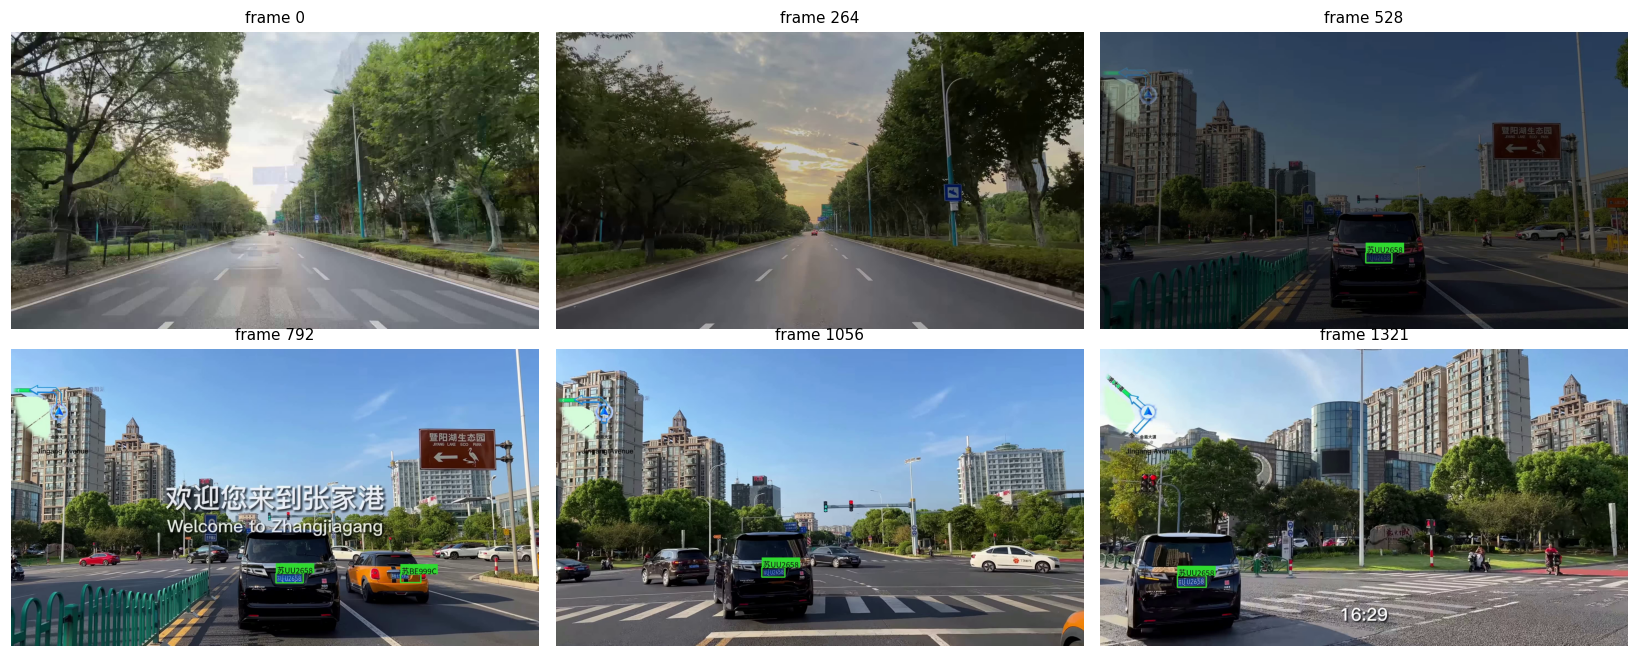

In [38]:
cap = cv2.VideoCapture(str(OUTPUT_VIDEO))
n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
if n == 0:
    print("⚠ output video is empty or couldn't be opened")
else:
    sample_idx = np.linspace(0, n-1, 6).astype(int)
    fig, axes = plt.subplots(2, 3, figsize=(15, 6))
    for ax, idx in zip(axes.ravel(), sample_idx):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ok, frame = cap.read()
        if not ok: ax.axis("off"); continue
        ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        ax.set_title(f"frame {int(idx)}", fontsize=10)
        ax.axis("off")
    plt.tight_layout(); plt.show()
cap.release()